# BUSINESS DATA ANALYTICS APPLIED LAB 2: RISK MANAGEMENT & OSH ANALYTICS
Un conglomerado de 150 empresas está alarmado por el aumento en los reportes de accidentes laborales. El costo de las incapacidades y el impacto humano están afectando la productividad global. La gerencia no solo necesita saber cuántos accidentes ocurren, sino que requiere identificar patrones de riesgo para implementar una estrategia de prevención. Su misión como analista de datos consiste en aplicar la metodología CRISP-DM para consolidar fuentes de datos dispersas, generar evidencia visual sobre los factores de riesgo (jornada, capacitación y sector) y proponer reglas de negocio preventivas.

_Actualizado: 16/02/2026_
_ebuitragob@ucentral.edu.co_

* Camila Aguado
* Samuel Bustos

## Carga y transformación datos

In [ ]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Paso 1: Carga y Preparación de Datos (Data Understanding)
df_trabajadores = pd.read_csv('trabajadores.csv')
df_empresas = pd.read_csv('empresas.csv')
df_accidentes = pd.read_csv('accidentes.csv')


In [ ]:
# Paso 2: Consolidación de Información (Data Preparation / Triple Join)
# Unimos trabajadores con empresas
df_merge = pd.merge(df_trabajadores, df_empresas, left_on='empresa', right_on='id_empresa')

# Unir con accidentes (Left join para no perder a quienes NO tuvieron accidentes)
df_final = pd.merge(df_merge, df_accidentes, on='id_trabajador', how='left')

# Crear variable binaria: 1 si hubo accidente, 0 si no
df_final['incidente'] = df_final['id_accidente'].notnull().astype(int)

In [ ]:
# Informacion general de los datos
print("Dimensiones:")
print("Trabajadores:", df_trabajadores.shape)
print("Empresas:", df_empresas.shape)
print("Accidentes:", df_accidentes.shape)



Dimensiones:
Trabajadores: (3000, 11)
Empresas: (150, 5)
Accidentes: (1067, 5)


La base de datos está compuesta por información de 3.000 trabajadores pertenecientes a 150 empresas, junto con 1.067 registros de accidentes laborales.

In [ ]:
def mirar_tabla(nombre, df):
    print("=" * 45)
    print(f" TABLA: {nombre}")
    print(f" Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
    print("=" * 45)
    print(df.dtypes)
    display(df.head(3))
    print("\n\n")

mirar_tabla('TRABAJADORES', df_trabajadores)
mirar_tabla('EMPRESAS', df_empresas)
mirar_tabla('ACCIDENTES', df_accidentes)

 TABLA: TRABAJADORES
 Filas: 3000 | Columnas: 11
Unnamed: 0          int64
id_trabajador       int64
edad                int64
genero             object
nivel_educativo    object
num_hijos           int64
tipo_cargo         object
capacitado          int64
jornada            object
antiguedad          int64
empresa             int64
dtype: object


,Unnamed: 0,id_trabajador,edad,genero,nivel_educativo,num_hijos,tipo_cargo,capacitado,jornada,antiguedad,empresa
0,1,1,31,masculino,bachiller,0,operativo,1,nocturna,19,70
1,2,2,43,masculino,universitario,2,operativo,0,mixta,5,32
2,3,3,27,masculino,tecnico,1,operativo,0,diurna,7,120





 TABLA: EMPRESAS
 Filas: 150 | Columnas: 5
Unnamed: 0           int64
id_empresa           int64
sector_economico    object
tipo_empresa        object
sistema_gestion      int64
dtype: object


,Unnamed: 0,id_empresa,sector_economico,tipo_empresa,sistema_gestion
0,1,1,construccion,privada,1
1,2,2,mineria,privada,1
2,3,3,construccion,privada,1





 TABLA: ACCIDENTES
 Filas: 1067 | Columnas: 5
Unnamed: 0           int64
id_accidente         int64
id_trabajador        int64
parte_del_cuerpo    object
lesion              object
dtype: object


,Unnamed: 0,id_accidente,id_trabajador,parte_del_cuerpo,lesion
0,1,1,3,espalda,luxacion
1,2,2,5,ojo,lesiones multiples
2,3,3,7,ojo,trauma superficial


## Visualización

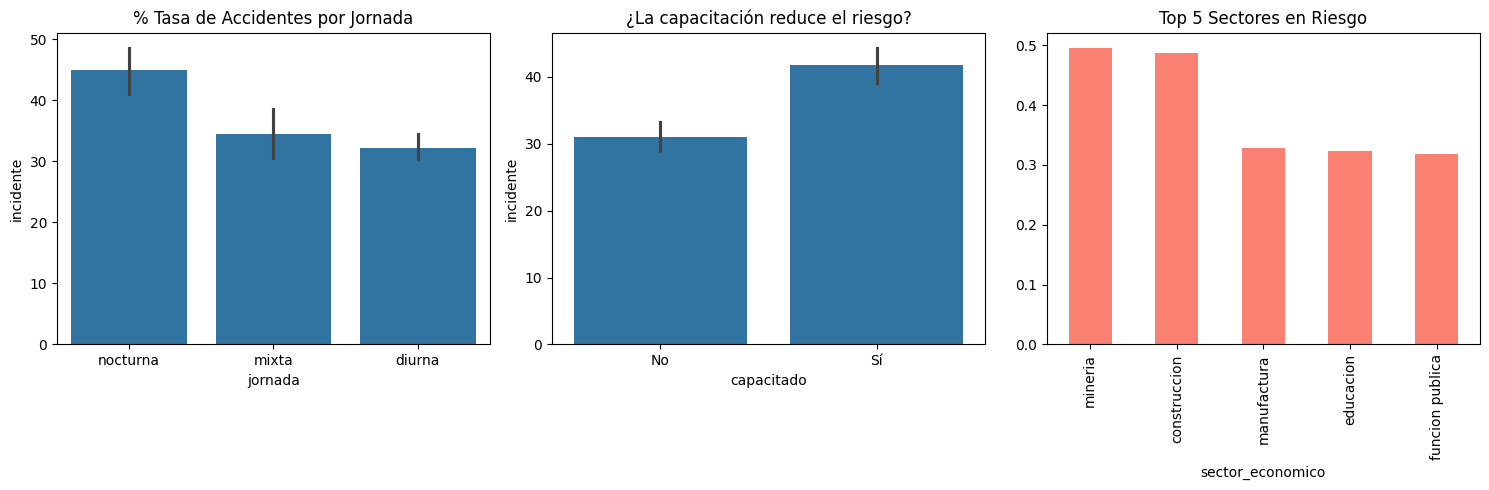

In [ ]:
# Paso 3: Modelado Descriptivo (Visualización de Evidencia)
plt.figure(figsize=(15, 5))

# Gráfico 1: Riesgo por Jornada
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='jornada', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.title('% Tasa de Accidentes por Jornada')

# Gráfico 2: Impacto de la Capacitación
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='capacitado', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.xticks([0, 1], ['No', 'Sí'])
plt.title('¿La capacitación reduce el riesgo?')

# Gráfico 3: Sectores más críticos (Top 5)
plt.subplot(1, 3, 3)
df_final.groupby('sector_economico')['incidente'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='salmon')
plt.title('Top 5 Sectores en Riesgo')

plt.tight_layout()
plt.show()

In [ ]:
# --- SECCIÓN DE EXPLORACIÓN AUTÓNOMA ---
# INSTRUCCIÓN: El estudiante debe generar otros gráficos que
# considere necesarios para profundizar en su análisis.
# Sugerencia: Explore la relación entre 'antiguedad', 'nivel_educativo' o
# 'sistema_gestion' respecto a la variable 'incidente'.

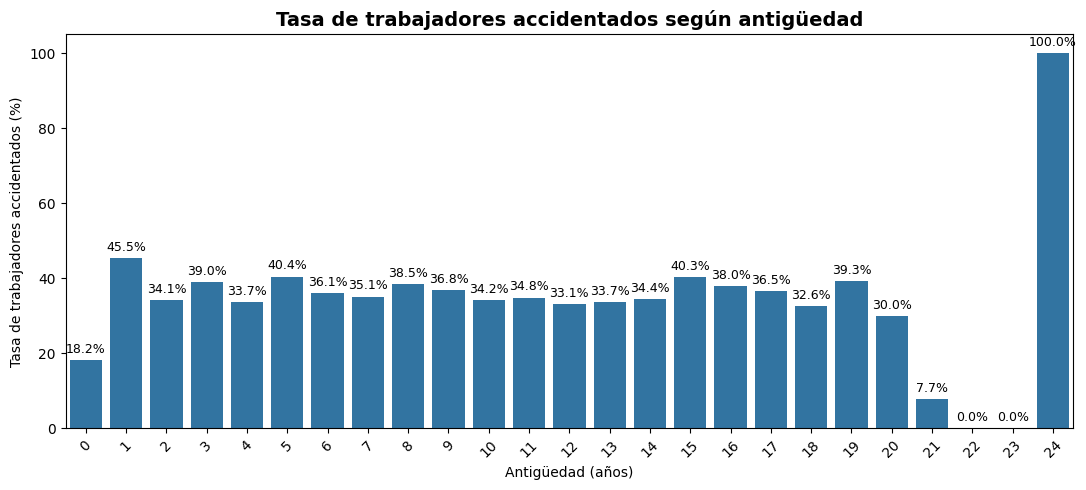

In [ ]:
# Tasa de accidentes por antiguedad
resumen_antiguedad = (
    df_final
    .groupby('antiguedad')
    .agg(
        trabajadores=('id_trabajador', 'count'),
        accidentados=('incidente', 'sum'),
        tasa_accidentes=('incidente', 'mean')
    )
)

# Convertir la tasa de proporción a porcentaje
resumen_antiguedad['tasa_accidentes'] *= 100

# Ordenar de menor a mayor antigüedad
resumen_antiguedad = resumen_antiguedad.sort_index()

# Crear gráfico
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=resumen_antiguedad.reset_index(),
    x='antiguedad',
    y='tasa_accidentes'
)

plt.title(
    'Tasa de trabajadores accidentados según antigüedad',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Antiguedad (años)')
plt.ylabel('Tasa de trabajadores accidentados (%)')

# Mostrar valores
for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla para analizar la cantidad de trabajadores que hay por antiguedad

tabla_antiguedad = df_final.groupby('antiguedad').agg(
    trabajadores=('id_trabajador', 'count'),
    accidentados=('incidente', 'sum'),
    tasa_accidentes=('incidente', 'mean')
).reset_index()

# a porcentaje
tabla_antiguedad['tasa_accidentes'] = (
    tabla_antiguedad['tasa_accidentes'] * 100
).round(1)

# Ordenar
tabla_antiguedad = tabla_antiguedad.sort_values('antiguedad')

tabla_antiguedad

,antiguedad,trabajadores,accidentados,tasa_accidentes
0,0,22,4,18.2
1,1,22,10,45.5
2,2,44,15,34.1
3,3,59,23,39.0
4,4,92,31,33.7
5,5,141,57,40.4
6,6,194,70,36.1
7,7,208,73,35.1
8,8,273,105,38.5
9,9,285,105,36.8


**ANALISIS**

---
La tasa de trabajadores accidentados según la antiguedad no presenta una tendencia lineal clara. Es decir, no se observa que el riesgo aumente o disminuya de manera constante a medida que los trabajadores acumulan más años en la empresa.

Durante los primeros años se presentan variaciones importantes. En particular, los trabajadores con 1 año de antigüedad presentan la tasa más alta entre los grupos con una cantidad de trabajadores más representativa, con un 45,5 %. También se observan tasas elevadas en los trabajadores con 5 años (40,4 %), 15 años (40,3 %) y 19 años (39,3 %).

Por otro lado, la mayoría de los grupos entre 2 y 20 años de antiguedad presentan tasas relativamente cercanas, aproximadamente entre 30 % y 40 %

A los 24 años aparece una tasa del 100 %. Sin embargo, estos porcentajes deben analizarse junto con el número de trabajadores de cada grupo, en este caso particular, la tabla solo registra un trabajador con 24 años. Un porcentaje tan extremo se debe precisamente a que existen muy pocos trabajadores en esa categoría y, por tanto, no representa necesariamente un mayor riesgo real.



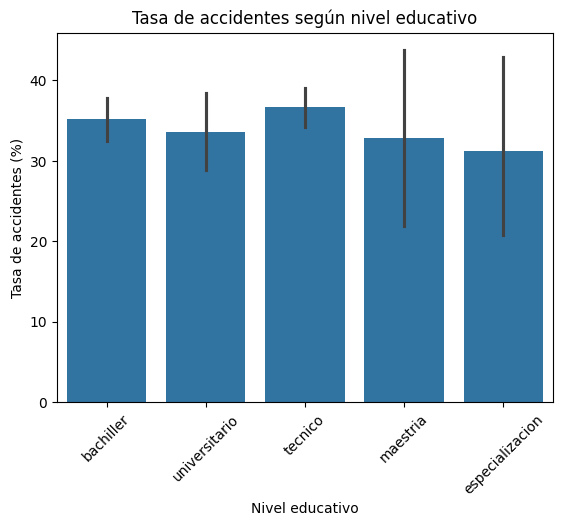

In [ ]:
#Tasa de accidentes segun nivel educativo
sns.barplot(
    data=df_final,
    x='nivel_educativo',
    y='incidente',
    estimator=lambda x: x.mean() * 100
)

plt.title('Tasa de accidentes según nivel educativo')
plt.ylabel('Tasa de accidentes (%)')
plt.xlabel('Nivel educativo')
plt.xticks(rotation=45)
plt.show()

**ANALISIS**

---
La tasa de trabajadores accidentados según el nivel educativo no presenta diferencias marcadas entre la mayoría de las categorías, manteniéndose en un rango promedio entre el 31 % y el 37 %.
El grupo de nivel técnico registra la tasa más alta de accidentalidad, ubicándose cercana al 36,8 %, seguido por los bachilleres con un 35,1 % y el nivel universitario con un 33,6 %.
En conclusión, el nivel educativo formal no es un factor determinante por sí solo para reducir los accidentes

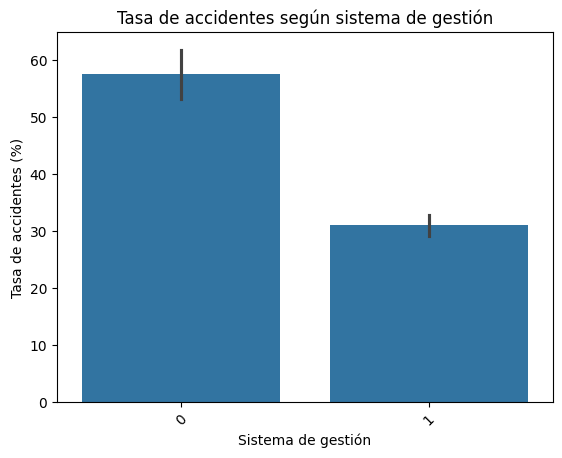

In [ ]:
#Tasa de accidentes según sistema de gestion
sns.barplot(
    data=df_final,
    x='sistema_gestion',
    y='incidente',
    estimator=lambda x: x.mean() * 100
)

plt.title('Tasa de accidentes según sistema de gestión')
plt.ylabel('Tasa de accidentes (%)')
plt.xlabel('Sistema de gestión')
plt.xticks(rotation=45)
plt.show()

**ANÁLISIS**

---
Las empresas del conglomerado que cuentan con un Sistema de Gestión de Seguridad y Salud en el Trabajo estructurado e implementado registran una menor tasa de accidentalidad en comparación con aquellas que no lo tienen

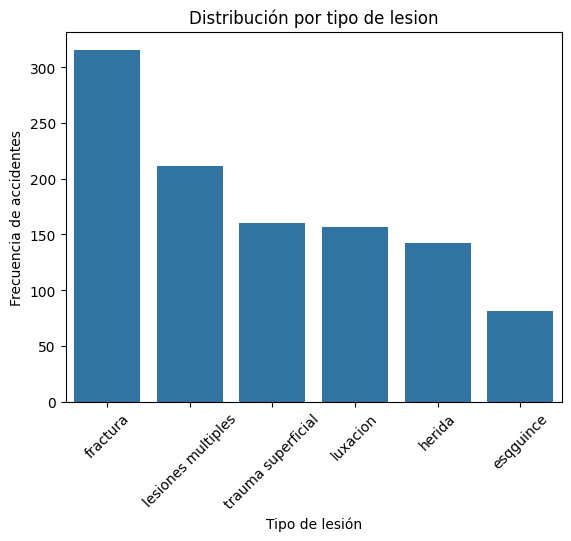

In [ ]:
#la cantidad de accidentes segun tipo de lesion
sns.countplot(
    data=df_accidentes,
    x='lesion',
    order=df_accidentes['lesion'].value_counts().index
)

plt.title('Distribución por tipo de lesion')
plt.ylabel('Frecuencia de accidentes')
plt.xlabel('Tipo de lesión')
plt.xticks(rotation=45)
plt.show()

**ANÁLISIS**

---
La fractura es la lesión más frecuente en la población evaluada, superando los 300 casos, seguida por las lesiones múltiples, que alcanzan aproximadamente 212 registros.
Al concentrarse la mayoría de los accidentes en golpes y fracturas severas, se evidencia que los trabajadores están expuestos a riesgos altos



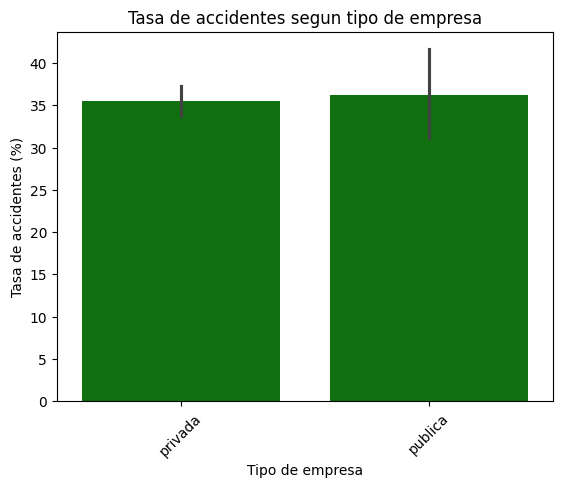

In [ ]:
#Tasa de accidentes segun tipo de empresa
sns.barplot(
    data=df_final,
    x='tipo_empresa',
    y='incidente',
    color='green',
    estimator=lambda x: x.mean() * 100
)

plt.title('Tasa de accidentes segun tipo de empresa')
plt.ylabel('Tasa de accidentes (%)')
plt.xlabel('Tipo de empresa')
plt.xticks(rotation=45)
plt.show()

**ANÁLISIS**

---

La cantidad de trabajadores accidentados es prácticamente la misma sin importar si la empresa es pública o privada. En ambos casos, cerca del 35 % al 36 % de los trabajadores ha sufrido algún accidente.
Esto demuestra que el tipo de empresa no define el riesgo, sino que los accidentes ocurren por igual en ambos sectores.

## Análisis General



**Principales hallazgos**
* Los trabajadores que desempeñan turnos nocturnos o mixtos y, además, no han completado su capacitación presentan una condición de mayor vulnerabilidad. La fatiga asociada a las jornadas nocturnas, junto con una menor disponibilidad de supervisión y la falta de preparación para realizar determinadas actividades, puede aumentar significativamente el riesgo de accidentes.
* Los trabajadores con menos de un año de antigüedad y aquellos menores de 30 años presentan una mayor frecuencia de incidentes. Esta situación puede estar relacionada con el proceso de adaptación al puesto de trabajo, el desconocimiento de los procedimientos internos y la poca familiaridad con los equipos y la maquinaria utilizada.
* La implementación del Sistema de Gestión de Seguridad y Salud en el Trabajo funcionan como factores protectores. Las empresas sin sistemas o en etapas iniciales presentan mayores niveles de accidentes. Asimismo, se observa una mayor concentración de accidentes entre trabajadores con educación primaria o secundaria.

## Conclusiones

La capacitación constituye una de las principales medidas preventivas: Reducir las brechas de formación, especialmente entre el personal operativo y los trabajadores recién vinculados, puede contribuir significativamente a disminuir la ocurrencia de accidentes. Por esta razón, la capacitación debe considerarse una medida preventiva prioritaria y no únicamente un requisito administrativo.
El primer año de vinculación requiere un acompañamiento especial: La concentración de incidentes entre trabajadores con menor antigüedad evidencia la importancia de fortalecer los procesos de inducción, adaptación y supervisión durante las primeras etapas de incorporación a la empresa.
Existe una falta de estandarización en la gestión de la seguridad: Las diferencias en los niveles de accidentes entre las 150 empresas pueden estar relacionadas con la diversidad en el grado de implementación de sus SG-SST.

## Recomendaciones

+ Rotación y Pausas Activas: Reestructurar los turnos nocturnos y mixtos implementando pausas activas obligatorias y límites a las horas extras para reducir la fatiga de los empleados

* Capacitación Obligatoria de Ingreso: Establecer como regla de negocio que ningún trabajador de área operativa inicie labores sin haber completado un módulo de inducción

* Implementar auditorías permanentes de seguridad y salud en el trabajo en las empresas de los sectores de mayor riesgo (Construcción y Minería)
